In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install timm==0.9.12
!pip install focal-loss
!pip install matplotlib seaborn scikit-learn h5py


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

import numpy as np
import h5py
import timm
import matplotlib.pyplot as plt
import seaborn as sns

from focal_loss.focal_loss import FocalLoss
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


In [3]:
DATASET_ROOT = "/content/drive/MyDrive/morph_project/processed"

TRAIN_H5 = f"{DATASET_ROOT}/train.h5"
TEST_H5  = f"{DATASET_ROOT}/test.h5"

with h5py.File(TRAIN_H5, 'r') as f:
    X_train_full = np.array(f["X"])
    y_train_full = np.array(f["y"])

with h5py.File(TEST_H5, 'r') as f:
    X_test = np.array(f["X"])
    y_test = np.array(f["y"])

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (5741, 224, 224, 3)
Val: (1436, 224, 224, 3)
Test: (1803, 224, 224, 3)


In [4]:
class NumpyDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.uint8)
        img = transforms.ToPILImage()(img)
        label = int(self.y[idx])
        if self.transform:
            img = self.transform(img)
        return img, label


In [5]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.RandomAffine(degrees=5, translate=(0.02, 0.02)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


In [6]:
train_dataset = NumpyDataset(X_train, y_train, transform_train)
val_dataset   = NumpyDataset(X_val,   y_val,   transform_test)
test_dataset  = NumpyDataset(X_test,  y_test,  transform_test)

# Compute per-class weights
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts

sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [7]:
class Swin224Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0,
            drop_path_rate=0.2
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model = Swin224Classifier().to(device)


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
freeze_ratio = 0.7
params = list(model.backbone.parameters())
freeze_until = int(len(params) * freeze_ratio)

for i, p in enumerate(params):
    if i < freeze_until:
        p.requires_grad = False

print("Backbone partially frozen (70%).")


Backbone partially frozen (70%).


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)  # shape = [batch_size]
        pt = torch.exp(-ce_loss)            # pt = probability of correct class

        focal_term = (1 - pt) ** self.gamma
        loss = self.alpha * focal_term * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


In [15]:
criterion = FocalLoss(alpha=0.75, gamma=2).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15,
    eta_min=1e-6
)

print("Criterion, optimizer, scheduler ready!")


Criterion, optimizer, scheduler ready!


In [16]:
scaler = torch.amp.GradScaler(device.type)

best_val_acc = 0
best_model_path = "/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth"

def accuracy(outputs, labels):
    return (outputs.argmax(1) == labels).float().mean().item()

for epoch in range(15):
    model.train()
    train_loss = 0
    train_acc = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()   # <- Now DEFINITELY defined

        with torch.amp.autocast(device.type):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_acc += accuracy(outputs, labels)

    scheduler.step()

    # ========= VALIDATION =========
    model.eval()
    val_acc = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_acc += accuracy(outputs, labels)

    epoch_train_acc = train_acc / len(train_loader)
    epoch_val_acc = val_acc / len(val_loader)

    print(f"Epoch {epoch+1}/15 | Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print("🔥 Saved Best Model!")


Epoch 1/15 | Train Acc: 0.6449 | Val Acc: 0.7132
🔥 Saved Best Model!
Epoch 2/15 | Train Acc: 0.7429 | Val Acc: 0.6806
Epoch 3/15 | Train Acc: 0.7852 | Val Acc: 0.7799
🔥 Saved Best Model!
Epoch 4/15 | Train Acc: 0.8232 | Val Acc: 0.7410
Epoch 5/15 | Train Acc: 0.8560 | Val Acc: 0.7840
🔥 Saved Best Model!
Epoch 6/15 | Train Acc: 0.8764 | Val Acc: 0.7819
Epoch 7/15 | Train Acc: 0.8853 | Val Acc: 0.7958
🔥 Saved Best Model!
Epoch 8/15 | Train Acc: 0.8902 | Val Acc: 0.7896
Epoch 9/15 | Train Acc: 0.9121 | Val Acc: 0.8181
🔥 Saved Best Model!
Epoch 10/15 | Train Acc: 0.9099 | Val Acc: 0.8194
🔥 Saved Best Model!
Epoch 11/15 | Train Acc: 0.9161 | Val Acc: 0.8076
Epoch 12/15 | Train Acc: 0.9229 | Val Acc: 0.8229
🔥 Saved Best Model!
Epoch 13/15 | Train Acc: 0.9285 | Val Acc: 0.8201
Epoch 14/15 | Train Acc: 0.9247 | Val Acc: 0.8229
Epoch 15/15 | Train Acc: 0.9276 | Val Acc: 0.8208


In [17]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []
all_probs = []

softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        probs = softmax(outputs)[:, 1].cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9113    0.8623    0.8861      1489
           1     0.4797    0.6019    0.5339       314

    accuracy                         0.8170      1803
   macro avg     0.6955    0.7321    0.7100      1803
weighted avg     0.8361    0.8170    0.8248      1803



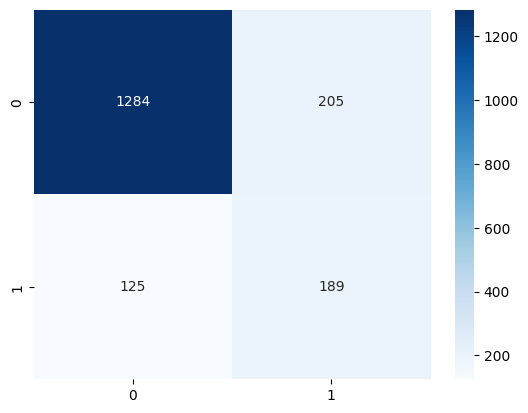

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()


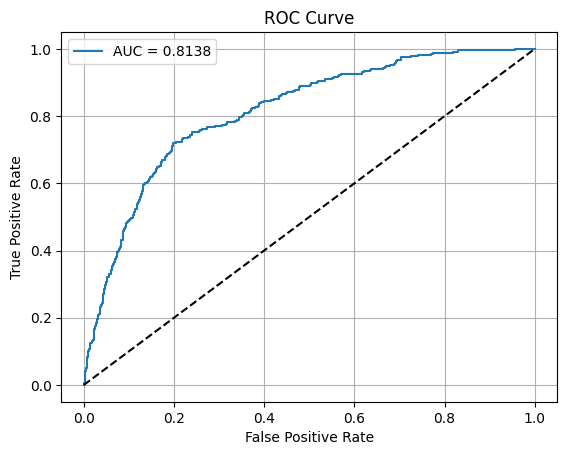

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score = roc_auc_score(all_labels, all_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [21]:
# ============================================
# 1. IMPORTS
# ============================================
from google.colab import files
from PIL import Image
import torch
import torch.nn as nn
import timm
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================
# 2. DEFINE SWIN-TINY 224 MODEL (must match training)
# ============================================
class Swin224Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=False,    # VERY IMPORTANT: keep False at inference
            num_classes=0
        )
        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x


# ============================================
# 3. LOAD BEST SAVED MODEL FROM DRIVE
# ============================================
model_path = "/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth"

model = Swin224Classifier().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("🔥 Best Swin224 Recall-Tuned Model Loaded Successfully!")


# ============================================
# 4. INFERENCE TRANSFORM (224×224)
# ============================================
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


# ============================================
# 5. PREDICTION FUNCTION
# ============================================
def predict_user_image(model, img_path):
    img = Image.open(img_path).convert("RGB")

    tensor = infer_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    classes = ["Licit", "Illicit"]
    confidence = float(probs[0][pred])

    print("\n==============================")
    print("Image:", img_path)
    print("Prediction:", classes[pred])
    print("Confidence:", round(confidence, 4))
    print("==============================")

    return classes[pred], confidence


# ============================================
# 6. UPLOAD IMAGES & PREDICT
# ============================================
uploaded = files.upload()

for filename in uploaded.keys():
    predict_user_image(model, filename)


Using device: cuda
🔥 Best Swin224 Recall-Tuned Model Loaded Successfully!


Saving casias1.png to casias1 (1).png

Image: casias1 (1).png
Prediction: Licit
Confidence: 0.849


In [23]:
import os

model_path = "/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth"

print("Model exists:", os.path.exists(model_path))


Model exists: True


In [24]:
train_acc_list = [
    0.6449, 0.7429, 0.7852, 0.8232, 0.8560,
    0.8764, 0.8853, 0.8902, 0.9121, 0.9099,
    0.9161, 0.9229, 0.9285, 0.9247, 0.9276
]

val_acc_list = [
    0.7132, 0.6806, 0.7799, 0.7410, 0.7840,
    0.7819, 0.7958, 0.7896, 0.8181, 0.8194,
    0.8076, 0.8229, 0.8201, 0.8229, 0.8208
]


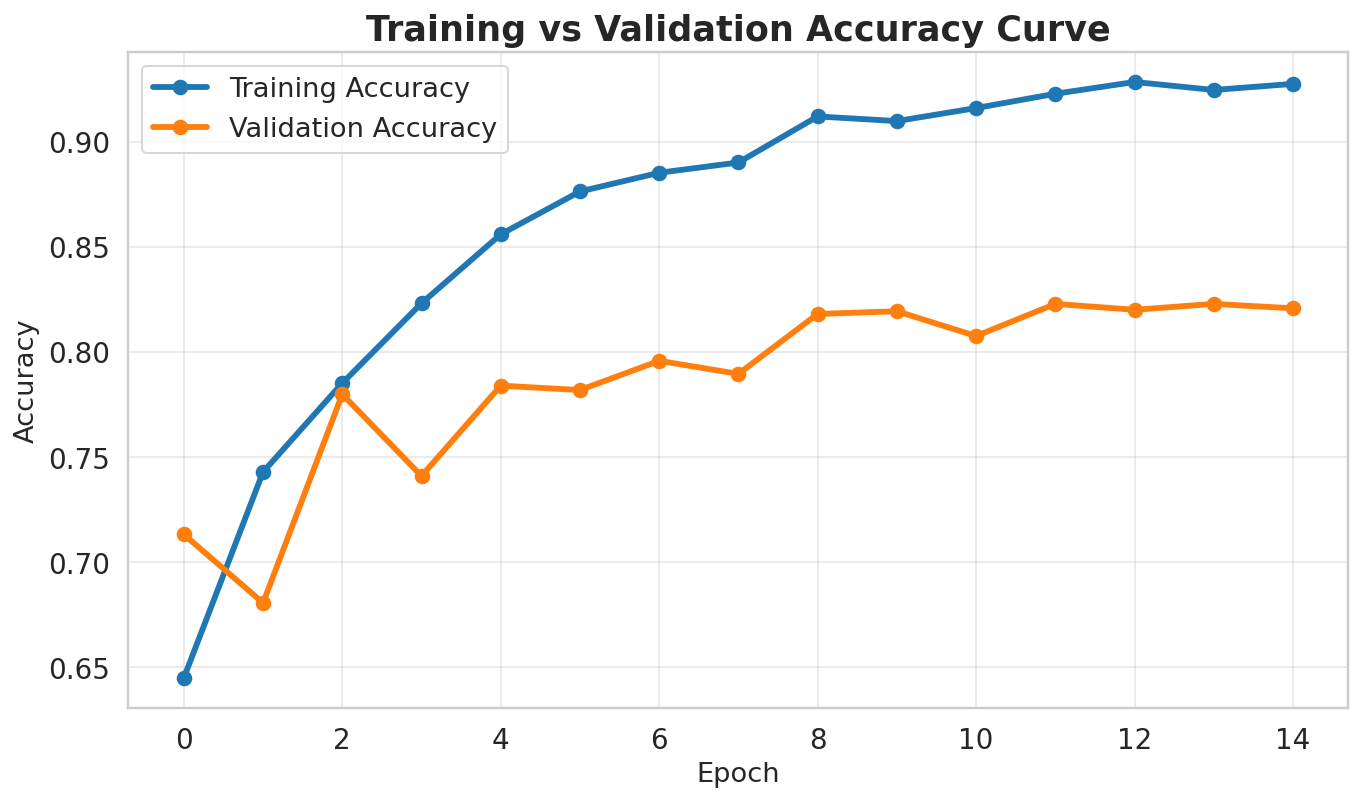

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style
sns.set_theme(style="whitegrid", font_scale=1.3)

plt.figure(figsize=(10, 6), dpi=140)

# Plot Training Accuracy
plt.plot(train_acc_list, marker='o', linewidth=3,
         markersize=7, label='Training Accuracy', color='#1f77b4')

# Plot Validation Accuracy
plt.plot(val_acc_list, marker='o', linewidth=3,
         markersize=7, label='Validation Accuracy', color='#ff7f0e')

# Labels and Title
plt.title("Training vs Validation Accuracy Curve", fontsize=18, weight='bold')
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)

# Grid & Legend
plt.grid(True, alpha=0.4)
plt.legend(fontsize=14)

# Tight layout for clean spacing
plt.tight_layout()

# Show
plt.show()
